# KDD99 Data Processing + Classical models.

This notebook applies the preprocessing pipeline used for KDD99 in the paper:
- binary target conversion 
- one-hot encoding 
- train/test split
- undersampling 
- min-max scaling 
- PCA

Then, we used UMAP to visualize both the data before and after preprocessing.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# print(PROJECT_ROOT)

In [2]:
from preprocessing import (
    timed_preprocess,
    plot_dimensionality_summary,
    plot_explained_variance,
    plot_pca_scatter,
    plot_umap,
    plot_umap_comparison,
)

In [4]:
result = timed_preprocess(
    percent10=True,   
    n_components=4,   
    vis_samples=25000, #5000
)


X_train = result["X_train_pca"]
X_test = result["X_test_pca"]
y_train = result["y_train"]
y_test = result["y_test"]

print("Full train:", X_train.shape)
print("Full test: ", X_test.shape)

print("Raw dimensions:", result["original_dim"])
print("After one-hot encoding:", result["encoded_dim"])
print("After PCA:", result["final_dim"])
print("Explained variance kept:", result["pca"].explained_variance_ratio_.sum())

KDD99 preprocessing time: 18.13s
Full train: (155644, 4)
Full test:  (98805, 4)
Raw dimensions: 41
After one-hot encoding: 118
After PCA: 4
Explained variance kept: 0.86063904


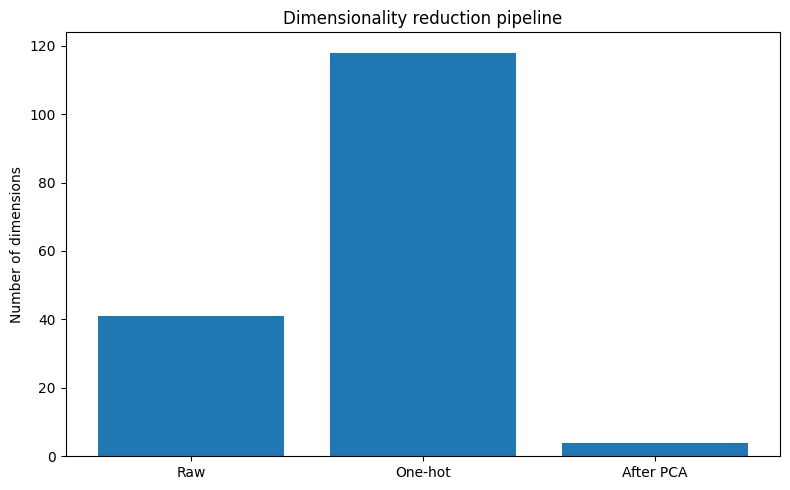

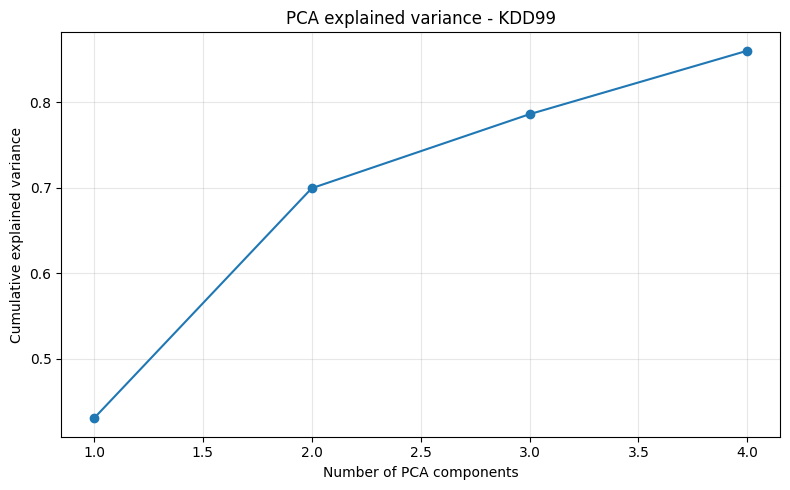

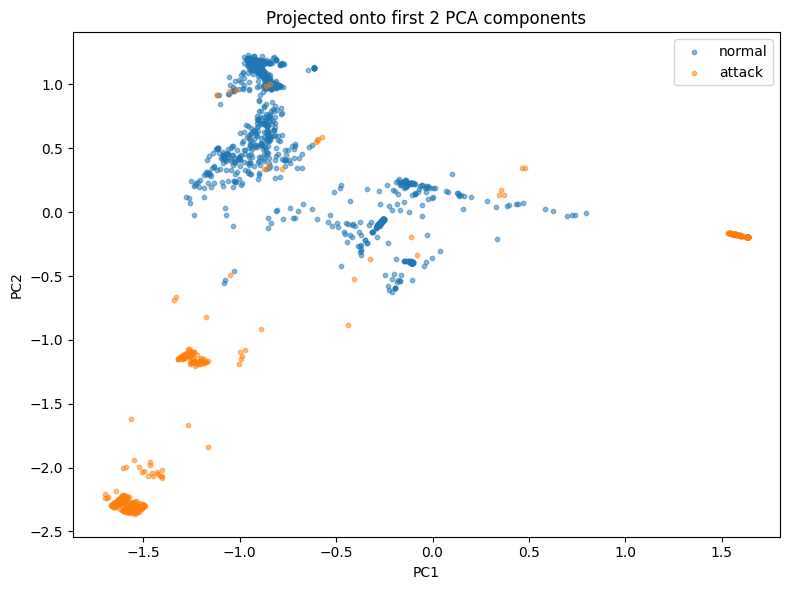

In [5]:
plot_dimensionality_summary(
    result["original_dim"],
    result["encoded_dim"],
    result["final_dim"],
)

plot_explained_variance(result["pca"], dataset="KDD99")
plot_pca_scatter(result["X_train_pca"], result["y_train"])

/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


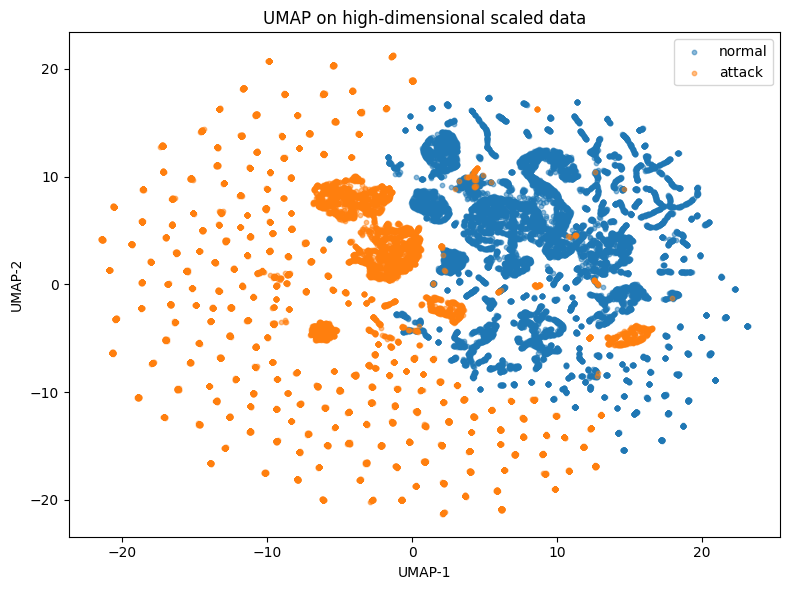

In [5]:
plot_umap(
    result["X_vis_scaled"],
    result["y_vis"],
    "UMAP on high-dimensional scaled data"
)

/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


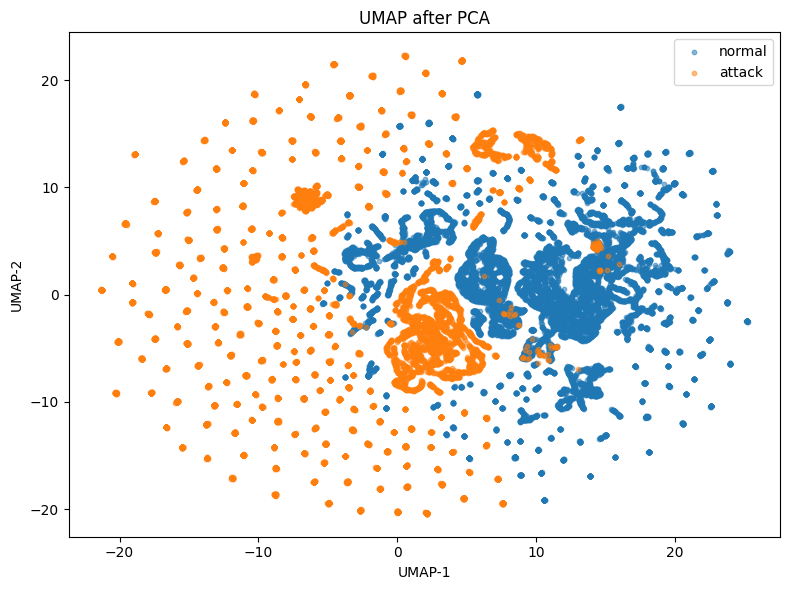

In [6]:
plot_umap(
    result["X_vis_pca"],
    result["y_vis"],
    "UMAP after PCA"
)

/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to ran

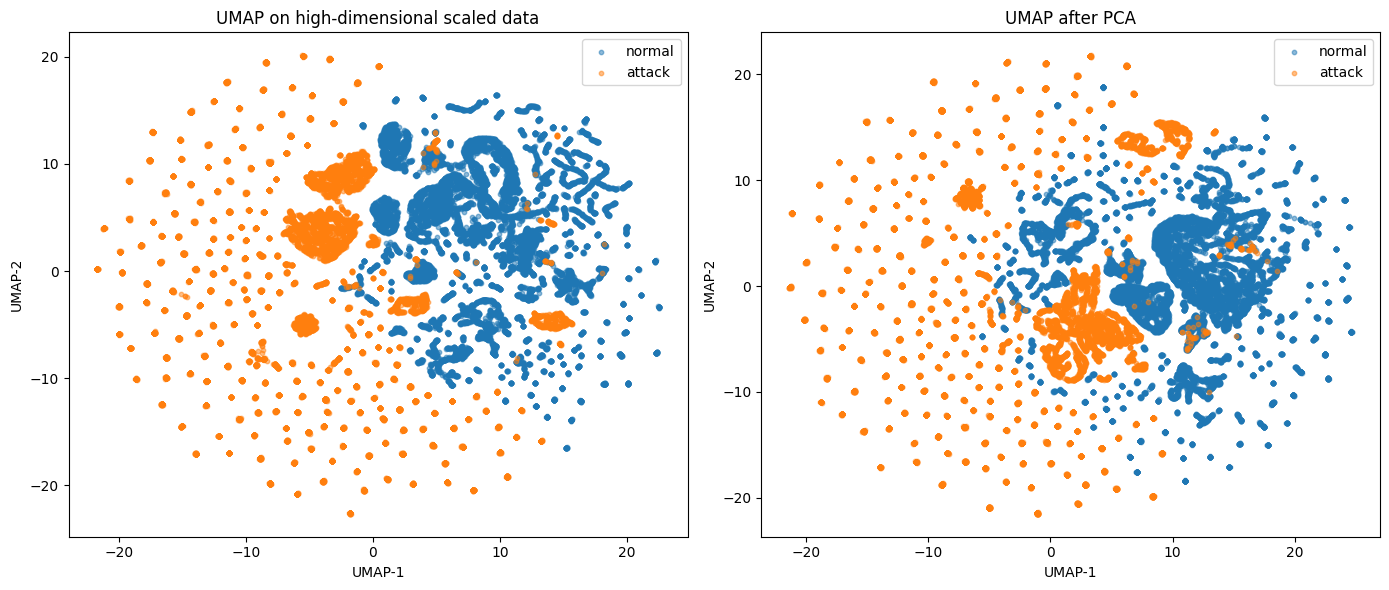

In [7]:
plot_umap_comparison(
    result["X_vis_scaled"],
    result["X_vis_pca"],
    result["y_vis"],
)

# Fitting a really Simple Logistic Regression to the data

Just to show that the data is really linearly separable. Just use the first 2 PC of PCA.

Linear classifier on the first 2 principal components
Accuracy: 0.9825
ROC-AUC:  0.9951
              precision    recall  f1-score   support

           0       0.93      0.98      0.96     19456
           1       1.00      0.98      0.99     79349

    accuracy                           0.98     98805
   macro avg       0.96      0.98      0.97     98805
weighted avg       0.98      0.98      0.98     98805



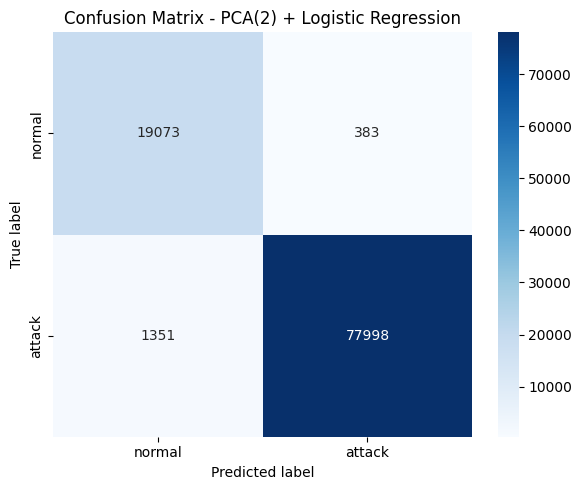

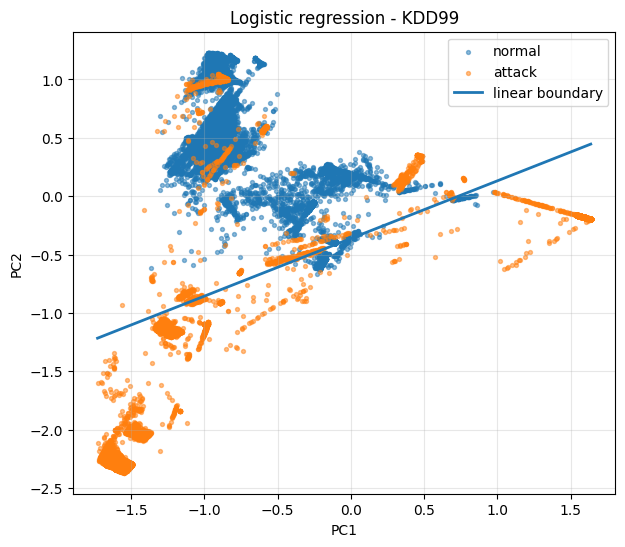

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Use the entire train/test sets, but only the first 2 PCA coordinates
X_train_pca2 = X_train[:, :2]
X_test_pca2 = X_test[:, :2]

lin_clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

lin_clf.fit(X_train_pca2, y_train)

y_pred_pca2 = lin_clf.predict(X_test_pca2)
y_prob_pca2 = lin_clf.predict_proba(X_test_pca2)[:, 1]

print("Linear classifier on the first 2 principal components")
print(f"Accuracy: {accuracy_score(y_test, y_pred_pca2):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_pca2):.4f}")
print(classification_report(y_test, y_pred_pca2))

cm_lg = confusion_matrix(y_test, y_pred_pca2)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["normal", "attack"],
    yticklabels=["normal", "attack"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - PCA(2) + Logistic Regression")
plt.tight_layout()
plt.show()

# visualize the learned linear decision boundary
plt.figure(figsize=(7, 6))

mask_normal = (y_test == 0)
mask_attack = (y_test == 1)

plt.scatter(
    X_test_pca2[mask_normal, 0],
    X_test_pca2[mask_normal, 1],
    s=8,
    alpha=0.5,
    label="normal",
)

plt.scatter(
    X_test_pca2[mask_attack, 0],
    X_test_pca2[mask_attack, 1],
    s=8,
    alpha=0.5,
    label="attack",
)

w = lin_clf.coef_[0]
b = lin_clf.intercept_[0]

x_min, x_max = X_test_pca2[:, 0].min(), X_test_pca2[:, 0].max()
xs = np.linspace(x_min, x_max, 200)

if abs(w[1]) > 1e-12:
    ys = -(w[0] * xs + b) / w[1]
    plt.plot(xs, ys, linewidth=2, label="linear boundary")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Logistic regression - KDD99")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()